## Khai báo thư viện

In [54]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
data = pd.read_csv("datasets/DailyDelhiClimate_2013_2025.csv")

In [56]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Data Processing And Cleaning 

In [57]:
data.describe()

,meantemp,humidity,wind_speed,meanpressure
count,4749.000000,4749.000000,4749.000000,4749.000000
mean,25.521007,60.515002,6.876044,1008.935828
std,7.264789,17.147545,4.316583,101.119661
min,5.607385,10.000000,0.000000,-3.041667
25%,19.125000,49.562595,3.732064,1001.581877
50%,27.634758,62.314972,6.612846,1008.571429
75%,31.400000,72.622537,9.595772,1014.852198
max,41.518276,100.000000,42.220000,7679.333333


In [58]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4749 entries, 0 to 4748
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          4749 non-null   str    
 1   meantemp      4749 non-null   float64
 2   humidity      4749 non-null   float64
 3   wind_speed    4749 non-null   float64
 4   meanpressure  4749 non-null   float64
dtypes: float64(4), str(1)
memory usage: 185.6 KB


In [59]:
# Tổng số lượng giá trị bị thiếu
data.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [60]:
# Số chiều của bộ dữ liệu
data.shape

(4749, 5)

In [61]:
# Đếm tổng số bản ghi bị lặp
data.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

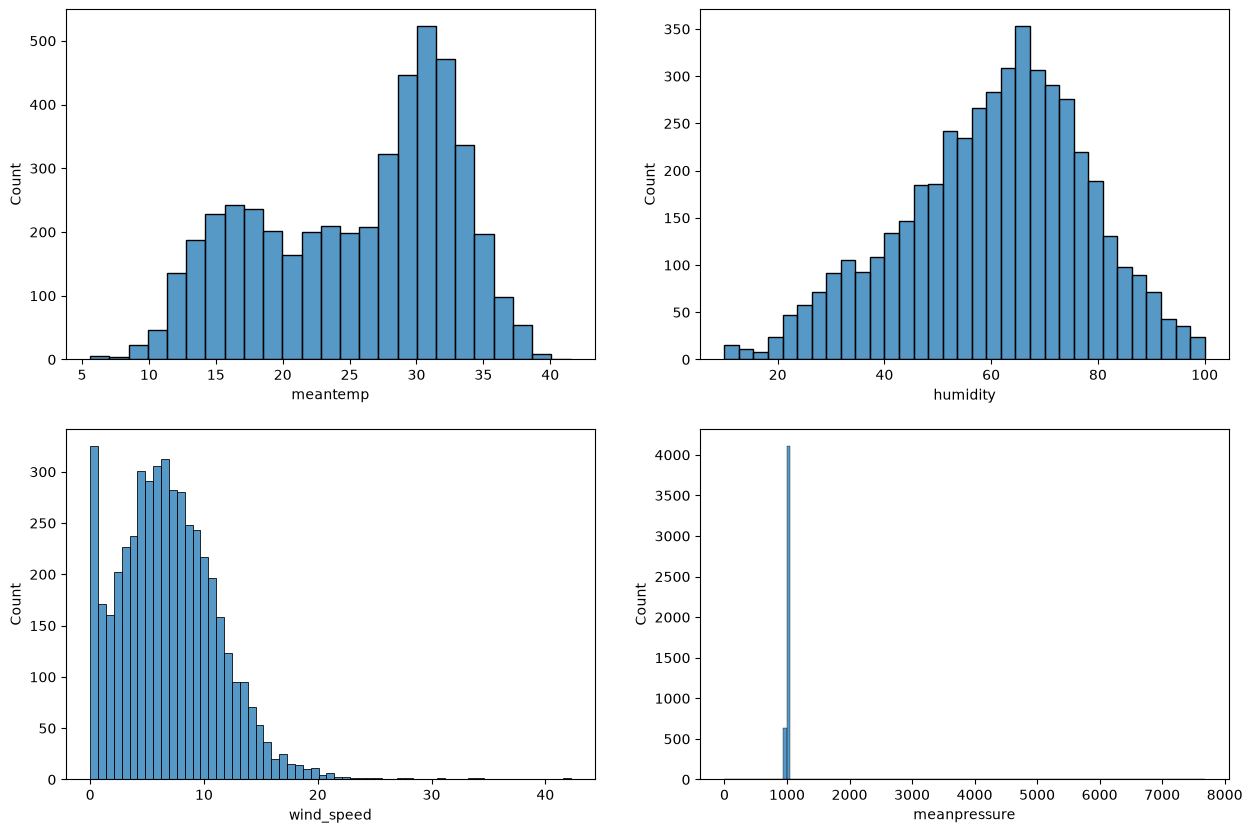

In [62]:
# Biểu đồ tần suất cho 4 trường thông tin của bộ dữ liệu
plt.figure(figsize=(15,10))
i=1
for col in data.iloc[:,1:5]:
    plt.subplot(2,2,i)
    sns.histplot(data[col])
    i=i+1

### 1. Chuẩn hóa dữ liệu thời gian:

In [63]:
data.index=pd.to_datetime(data.date)

In [64]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
date,,,,,
2013-01-01,2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,2013-01-05,6.000000,86.833333,3.700000,1016.500000


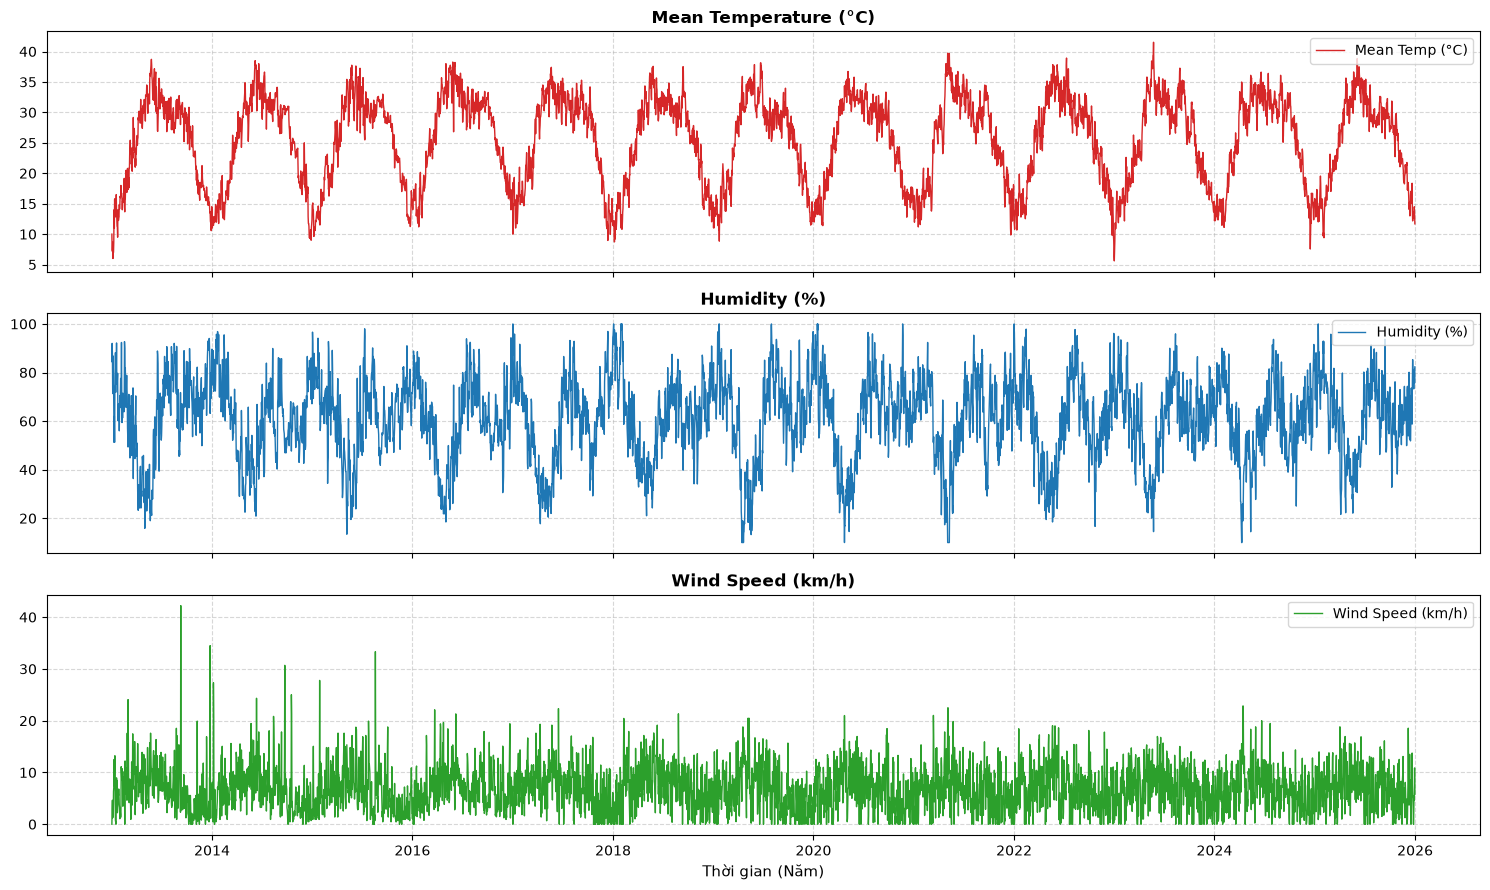

In [65]:
# Biểu đồ so sánh sự biến thiên của 3 chỉ số khí hậu (meantemp, humidity, wind_speed) theo thời gian
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

# 1. Nhiệt độ trung bình
axes[0].plot(data.index, data['meantemp'], color='#d62728', linewidth=1, label='Mean Temp (°C)')
axes[0].set_title('Mean Temperature (°C)', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right')

# 2. Độ ẩm
axes[1].plot(data.index, data['humidity'], color='#1f77b4', linewidth=1, label='Humidity (%)')
axes[1].set_title('Humidity (%)', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

# 3. Tốc độ gió
axes[2].plot(data.index, data['wind_speed'], color='#2ca02c', linewidth=1, label='Wind Speed (km/h)')
axes[2].set_title('Wind Speed (km/h)', fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right')

plt.xlabel('Thời gian (Năm)', fontsize=11)
plt.tight_layout()
plt.show()

=> Temperature (nhiệt độ) và Humidity (độ ẩm) tỷ lệ nghịch với nhau

### 2. Chuyển đổi datetime sang integer:

In [66]:
# Thêm tryiwngf thông tin day, hour, month
data['date'] = pd.to_datetime(data['date'])
data['day'] = data['date'].dt.day
data['hour'] = data['date'].dt.hour
data['month'] = data['date'].dt.month

In [67]:
data.head()

,date,meantemp,humidity,wind_speed,meanpressure,day,hour,month
date,,,,,,,,
2013-01-01,2013-01-01,10.000000,84.500000,0.000000,1015.666667,1,0,1
2013-01-02,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2,0,1
2013-01-03,2013-01-03,7.166667,87.000000,4.633333,1018.666667,3,0,1
2013-01-04,2013-01-04,8.666667,71.333333,1.233333,1017.166667,4,0,1
2013-01-05,2013-01-05,6.000000,86.833333,3.700000,1016.500000,5,0,1


### 3. Gom nhóm dữ liệu theo ngày:

In [68]:
# Tính giá trị trung bình theo ngày
data.groupby(by="day").mean(numeric_only=True)

,meantemp,humidity,wind_speed,meanpressure,hour,month
day,,,,,,
1,25.233241,62.421704,6.742894,1002.619826,0.0,6.464968
2,25.355423,61.725721,6.652557,1004.152645,0.0,6.500000
3,25.382015,61.122515,6.961008,1008.495635,0.0,6.500000
4,25.380891,61.084571,6.948625,1008.174452,0.0,6.500000
5,25.413627,61.084620,6.747209,1008.174696,0.0,6.500000
6,25.294478,61.316561,6.700002,1008.335153,0.0,6.500000
7,25.254207,61.032875,7.023864,1008.339891,0.0,6.500000
8,25.359715,59.862559,7.047909,1008.248987,0.0,6.500000
9,25.495321,59.764305,7.201427,1007.576526,0.0,6.500000


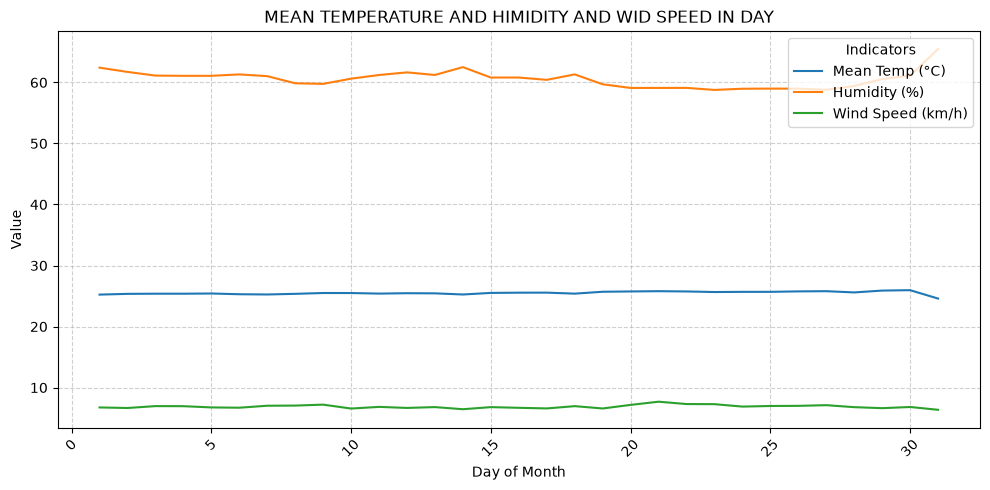

In [69]:
# Biểu đồ thể hiện mối tương quan giữa MeanTemp (Nhiệt độ), Humidity (độ ẩm), WindSpeed (sức gió) theo ngày
plt.figure(figsize=(10,5))
plt.title("MEAN TEMPERATURE AND HIMIDITY AND WID SPEED IN DAY")
sns.lineplot(data.groupby(by="day")['meantemp'].mean(), label="Mean Temp (°C)")
sns.lineplot(data.groupby(by="day")['humidity'].mean(), label="Humidity (%)")
sns.lineplot(data.groupby(by="day")['wind_speed'].mean(), label="Wind Speed (km/h)")

# Đặt tên các trục
plt.xticks(rotation=45)
plt.xlabel("Day of Month", fontsize=10)
plt.ylabel("Value", fontsize=10)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Indicators", loc="upper right")
plt.tight_layout()

plt.show()

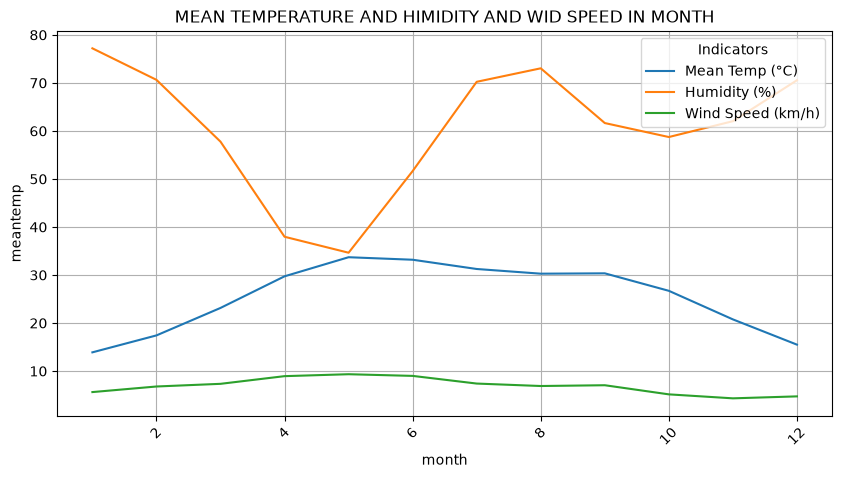

In [70]:
# Biểu đồ thể hiện mối tương quan giữa MeanTemp (Nhiệt độ), Humidity (độ ẩm), WindSpeed (sức gió) theo tháng
plt.figure(figsize=(10,5))
plt.title("MEAN TEMPERATURE AND HIMIDITY AND WID SPEED IN MONTH")
sns.lineplot(data.groupby(by="month")['meantemp'].mean(), label="Mean Temp (°C)")
sns.lineplot(data.groupby(by="month")['humidity'].mean(), label="Humidity (%)")
sns.lineplot(data.groupby(by="month")['wind_speed'].mean(), label="Wind Speed (km/h)")
plt.xticks(rotation=45)
plt.legend(title="Indicators", loc="upper right")
plt.grid()
plt.show()

### 4. Xu hướng nhiệt độ trung bình theo năm:

In [71]:
# Đánh index cho 'meantemp'
tempdata=data[['meantemp']]
tempdata.index=pd.to_datetime(data.date)

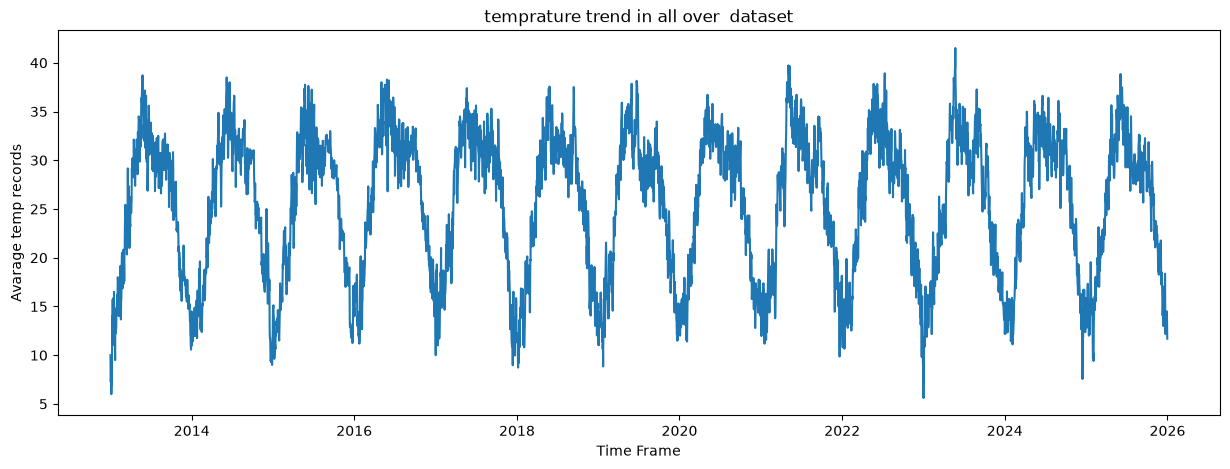

In [72]:
# Biểu đồ xu hướng nhiệt độ theo từng năm
plt.figure(figsize=(15,5))
plt.xlabel("Time Frame")
plt.ylabel("Avarage temp records")
plt.title("temprature trend in all over  dataset")
plt.plot(tempdata)
plt.show()

### 5. Ma trận tương quan của bộ dữ liệu:

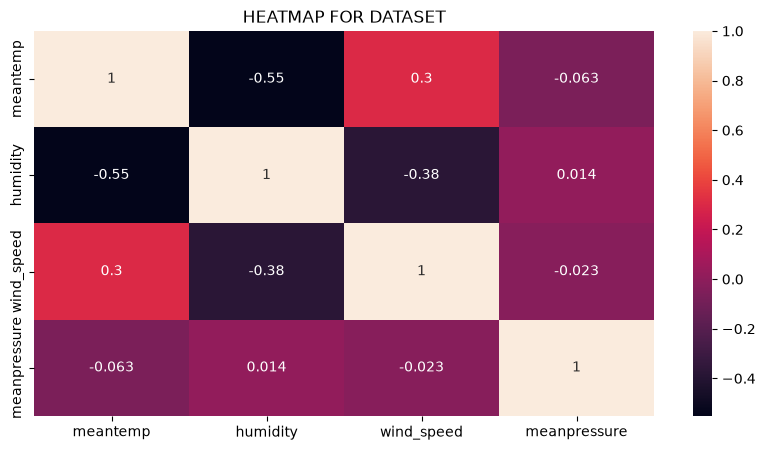

In [73]:
plt.figure(figsize=(10,5))
plt.title("HEATMAP FOR DATASET")
sns.heatmap(data.iloc[:,1:5].corr(), annot=True)
plt.show()

## Phân tích chuỗi thời gian Time Series

### Kiểm định tính dừng Adfuller:
Kiểm định Dickey-Fuller mở rộng (Augmented Dickey-Fuller - ADF test) là kiểm định thống kê dùng để xác định tính dừng của chuỗi dữ liệu thời gian.

In [74]:
# Library ADF
from statsmodels.tsa.stattools import adfuller  

In [75]:
# Lấy sai phân với bậc i
"""
tempdata_diff_i = tempdata.diff(i).dropna()
"""

## .diff(1) sẽ lấy y(t) - y(t-1)
tempdata_diff1 = tempdata.diff(1).dropna()

In [76]:
# Chỉ số đánh giá AIC

# Không sử dụng sai phân
adfuller_result_aic = adfuller(tempdata, autolag='AIC')

print("Chỉ số đánh giá AIC theo kiểm định ADF-test:")
print(f'+ ADF Statitcs of AIC: {adfuller_result_aic[0]}')
print(f'+ p_values of AIC: {adfuller_result_aic[1]}')
print()

# Kiểm định giả thiết
"""
H0: Chuỗi thời gian không có tính dừng
H1: Chuỗi thời gian có tính dừng
"""

""" Cách 1:
Nếu ADF Statitcs < Criteria Value => Bác bỏ H0 => chuỗi đã dừng
Nếu ADF Statitcs >= Criteria Value => Chấp nhận H0 => chuỗi chưa dừng
"""
for key, value in adfuller_result_aic[4].items():
    print(f'Criteria value với myn {key} là: {value}')

""" Cách 2:
Nếu p_values <= 0.5 => Bác bỏ H0 => chuỗi đã dừng
Nếu p_values > 0.5 => Chấp nhận H0 => chuỗi chưa dừng
"""
if adfuller_result_aic[1] <= 0.05:
    print("=> Kết luận: Chuỗi dữ liệu ĐÃ DỪNG (Stationary).")
else:
    print("=> Kết luận: Chuỗi dữ liệu CHƯA DỪNG (Non-stationary). Cần lấy sai phân bậc cao hơn.")

Chỉ số đánh giá AIC theo kiểm định ADF-test:
+ ADF Statitcs of AIC: -4.926786517922997
+ p_values of AIC: 3.092061983142906e-05

Criteria value với myn 1% là: -3.4317364930444034
Criteria value với myn 5% là: -2.8621526719690626
Criteria value với myn 10% là: -2.567096127411153
=> Kết luận: Chuỗi dữ liệu ĐÃ DỪNG (Stationary).


C:\Users\Acer\AppData\Local\Temp\ipykernel_18156\351462514.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adfuller_result_aic = adfuller(tempdata, autolag='AIC')


In [77]:
# Chỉ số đánh giá BIC

# Không sử dụng sai phân
adfuller_result_bic = adfuller(tempdata, autolag='BIC')

print("Chỉ số đánh giá BIC theo kiểm định ADF-test:")
print(f'+ ADF Statitcs of BIC: {adfuller_result_bic[0]}')
print(f'+ p_values of BIC: {adfuller_result_bic[1]}')
print()

# Kiểm định giả thiết
"""
H0: Chuỗi thời gian không có tính dừng
H1: Chuỗi thời gian có tính dừng
"""

""" Cách 1:
Nếu ADF Statitcs < Criteria Value => Bác bỏ H0 => chuỗi đã dừng
Nếu ADF Statitcs >= Criteria Value => Chấp nhận H0 => chuỗi chưa dừng
"""
for key, value in adfuller_result_bic[4].items():
    print(f'Criteria value với myn {key} là: {value}')

""" Cách 2:
Nếu p_values <= 0.5 => Bác bỏ H0 => chuỗi đã dừng
Nếu p_values > 0.5 => Chấp nhận H0 => chuỗi chưa dừng
"""
if adfuller_result_bic[1] <= 0.05:
    print("=> Kết luận: Chuỗi dữ liệu ĐÃ DỪNG (Stationary).")
else:
    print("=> Kết luận: Chuỗi dữ liệu CHƯA DỪNG (Non-stationary). Cần lấy sai phân bậc cao hơn.")

Chỉ số đánh giá BIC theo kiểm định ADF-test:
+ ADF Statitcs of BIC: -4.464379784390675
+ p_values of BIC: 0.00022792945217650423

Criteria value với myn 1% là: -3.4317300557133943
Criteria value với myn 5% là: -2.8621498280619924
Criteria value với myn 10% là: -2.567094613476278
=> Kết luận: Chuỗi dữ liệu ĐÃ DỪNG (Stationary).


C:\Users\Acer\AppData\Local\Temp\ipykernel_18156\1054336307.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adfuller_result_bic = adfuller(tempdata, autolag='BIC')


### Mô hình chuỗi thời gian ARIMA:

In [78]:
# Libraries ARIMA
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [79]:
# =========================================================
# 0. CHUẨN HÓA CHUỖI THỜI GIAN
# =========================================================

# Nếu có nhiều giá trị trong cùng một ngày, lấy giá trị trung bình của các giá trị đó
tempdata = tempdata.groupby(tempdata.index).mean()
tempdata = tempdata.sort_index()

# Đảm bảo tần suất hàng ngày
tempdata = tempdata.asfreq('D')

# Nội suy theo thời gian cho các ngày bị thiếu
tempdata = tempdata.interpolate(method='time')

# ---------------------------------------------------------
# 1. TÁCH DỮ LIỆU TRAIN / TEST
# ---------------------------------------------------------
last_train_data = '2025-03-31'
start_test_data = '2025-04-01'
end_test_data = '2025-04-24'

train = tempdata.loc[:last_train_data, 'meantemp']
test = tempdata.loc[start_test_data:end_test_data, 'meantemp']

# ---------------------------------------------------------
# 2. HUẤN LUYỆN MÔ HÌNH TRÊN TẬP TRAIN
# ---------------------------------------------------------
p, d, q = (1, 1, 1)
model = ARIMA(train, order=(p, d, q))
result = model.fit()
# Perform the Augmented Dickey-Fuller test

# ---------------------------------------------------------
# 3. DỰ BÁO TRÊN TẬP TEST
# ---------------------------------------------------------
predictions = result.predict(start=start_test_data, end=end_test_data)
print("Kết quả dự đoán:")
print(predictions)
print()

# ---------------------------------------------------------
# 4. TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ ĐỘ CHÍNH XÁC
# ---------------------------------------------------------
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test - predictions) / test)) * 100
accuracy = 100 - mape

print("=== KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC MÔ HÌNH ===")
print(f"MAE  (Sai số tuyệt đối trung bình) : {mae:.4f}")
print(f"RMSE (Căn sai số bình phương trung bình): {rmse:.4f}")
print(f"MAPE (Sai số phần trăm trung bình) : {mape:.2f}%")
print(f"Accuracy : {accuracy:.2f}%")

Kết quả dự đoán:
2025-04-01    27.212469
2025-04-02    26.759139
2025-04-03    26.490275
2025-04-04    26.330815
2025-04-05    26.236241
2025-04-06    26.180151
2025-04-07    26.146884
2025-04-08    26.127154
2025-04-09    26.115453
2025-04-10    26.108513
2025-04-11    26.104397
2025-04-12    26.101955
2025-04-13    26.100508
2025-04-14    26.099649
2025-04-15    26.099140
2025-04-16    26.098838
2025-04-17    26.098659
2025-04-18    26.098552
2025-04-19    26.098489
2025-04-20    26.098452
2025-04-21    26.098430
2025-04-22    26.098417
2025-04-23    26.098409
2025-04-24    26.098404
Freq: D, Name: predicted_mean, dtype: float64

=== KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC MÔ HÌNH ===
MAE  (Sai số tuyệt đối trung bình) : 3.0358
RMSE (Căn sai số bình phương trung bình): 3.9889
MAPE (Sai số phần trăm trung bình) : 9.84%
Accuracy : 90.16%


### Mô hình chuỗi thời gian SARIMA:

In [80]:
# Library
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [81]:
# =========================================================
# 0. CHUẨN HÓA CHUỖI THỜI GIAN
# =========================================================

# Nếu có nhiều giá trị trong cùng một ngày, lấy giá trị trung bình của các giá trị đó
tempdata = tempdata.groupby(tempdata.index).mean()
tempdata = tempdata.sort_index()

# Đảm bảo tần suất hàng ngày
tempdata = tempdata.asfreq('D')

# Nội suy theo thời gian cho các ngày bị thiếu
tempdata = tempdata.interpolate(method='time')

# ---------------------------------------------------------
# 1. TÁCH DỮ LIỆU TRAIN / TEST
# ---------------------------------------------------------
last_train_data = '2025-03-31'
start_test_data = '2025-04-01'
end_test_data = '2025-04-24'

train = tempdata.loc[:last_train_data, 'meantemp']
test = tempdata.loc[start_test_data:end_test_data, 'meantemp']

# ---------------------------------------------------------
# 2. HUẤN LUYỆN MÔ HÌNH SARIMA TRÊN TẬP TRAIN
# ---------------------------------------------------------
p, d, q = (1, 1, 1)
P, D, Q, m = (1, 1, 1, 7)  # m = 7 cho chu kỳ tuần hàng ngày

model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, m))
result = model.fit(disp=False)

# ---------------------------------------------------------
# 3. DỰ BÁO TRÊN TẬP TEST
# ---------------------------------------------------------
predictions = result.predict(start=start_test_data, end=end_test_data)
print("Kết quả dự đoán:")
print(predictions)
print()

# ---------------------------------------------------------
# 4. TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ ĐỘ CHÍNH XÁC
# ---------------------------------------------------------
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test - predictions) / test)) * 100
accuracy = 100 - mape

print("=== KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC MÔ HÌNH ===")
print(f"MAE  (Sai số tuyệt đối trung bình) : {mae:.4f}")
print(f"RMSE (Căn sai số bình phương trung bình): {rmse:.4f}")
print(f"MAPE (Sai số phần trăm trung bình) : {mape:.2f}%")
print(f"Accuracy : {accuracy:.2f}%")

Kết quả dự đoán:
2025-04-01    27.367521
2025-04-02    26.945903
2025-04-03    26.616511
2025-04-04    26.368623
2025-04-05    26.167465
2025-04-06    26.090513
2025-04-07    26.133189
2025-04-08    26.274558
2025-04-09    26.315818
2025-04-10    26.250801
2025-04-11    26.197373
2025-04-12    26.068441
2025-04-13    26.040679
2025-04-14    26.155530
2025-04-15    26.299150
2025-04-16    26.341230
2025-04-17    26.276794
2025-04-18    26.222923
2025-04-19    26.094528
2025-04-20    26.066942
2025-04-21    26.181054
2025-04-22    26.325012
2025-04-23    26.367299
2025-04-24    26.302982
Freq: D, Name: predicted_mean, dtype: float64

=== KẾT QUẢ ĐÁNH GIÁ ĐỘ CHÍNH XÁC MÔ HÌNH ===
MAE  (Sai số tuyệt đối trung bình) : 2.9823
RMSE (Căn sai số bình phương trung bình): 3.9093
MAPE (Sai số phần trăm trung bình) : 9.68%
Accuracy : 90.32%


### Dữ liệu thực tế:

In [82]:
# Giá trị thực tế ban đầu
actual=data['2025-04-01':'2025-04-24']['meantemp']

print("Giá trị thực tế:")
print(actual)

Giá trị thực tế:
date
2025-04-01    24.357118
2025-04-02    26.145602
2025-04-03    26.967557
2025-04-04    27.062229
2025-04-05    26.882030
2025-04-06    26.962129
2025-04-07    26.993805
2025-04-08    28.229268
2025-04-09    26.701275
2025-04-10    26.048662
2025-04-11    24.947612
2025-04-12    25.700240
2025-04-13    29.964961
2025-04-14    29.812126
2025-04-15    30.556536
2025-04-16    28.920222
2025-04-17    27.909914
2025-04-18    31.158303
2025-04-19    32.122442
2025-04-20    31.468405
2025-04-21    31.761535
2025-04-22    31.557100
2025-04-23    33.911942
2025-04-24    35.643101
Name: meantemp, dtype: float64


=> Mô hình ARIMA và SARIMA chỉ cho phép dự đoán khoảng start_date và end_date không quá lớn, khi khoảng dự đoán quá lớn sẽ dẫn đến sai lệch về khả năng dự đoán của mô hình.

## So sánh độ chính xác giữa các mô hình

### Phân chia tập dữ liệu:

In [83]:
# Đặt lại index của datasets
data.reset_index(drop=True, inplace=True)

In [84]:
x=data.drop(['meantemp','date'], axis=1)
print(x)

       humidity  wind_speed  meanpressure  day  hour  month
0     84.500000    0.000000   1015.666667    1     0      1
1     92.000000    2.980000   1017.800000    2     0      1
2     87.000000    4.633333   1018.666667    3     0      1
3     71.333333    1.233333   1017.166667    4     0      1
4     86.833333    3.700000   1016.500000    5     0      1
...         ...         ...           ...  ...   ...    ...
4744  73.269051    2.056740   1020.077532   27     0     12
4745  77.346413    5.496399   1018.373416   28     0     12
4746  81.300251    4.602666   1017.558687   29     0     12
4747  75.592977   10.869282   1020.805469   30     0     12
4748  82.326431    5.750092   1021.484140   31     0     12

[4749 rows x 6 columns]


In [85]:
y=data['meantemp']
print(y)

0       10.000000
1        7.400000
2        7.166667
3        8.666667
4        6.000000
          ...    
4744    12.798865
4745    12.684163
4746    14.496436
4747    13.452991
4748    11.691297
Name: meantemp, Length: 4749, dtype: float64


### Spliting Data:

In [86]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y)

### Data Scalling:

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = pd.DataFrame(scaler.fit_transform(x_train), columns = x_train.columns)
x_test = pd.DataFrame(scaler.fit_transform(x_test), columns = x_test.columns)

In [88]:
x_train.head()

,humidity,wind_speed,meanpressure,day,hour,month
0,-0.571027,0.792173,-0.042580,1.158890,0.0,0.417208
1,0.715479,-0.798075,-0.063262,-0.194272,0.0,0.417208
2,0.682868,0.538053,0.082006,0.031255,0.0,-1.323820
3,0.678180,-1.103927,0.080455,-0.194272,0.0,-1.323820
4,-1.595990,-0.148936,-0.090180,-0.870854,0.0,-0.163135


In [89]:
x_test.head()

,humidity,wind_speed,meanpressure,day,hour,month
0,-0.267145,0.294290,-0.181321,-0.550655,0.0,0.752033
1,0.543392,-0.980895,0.385249,-1.248444,0.0,1.620270
2,-1.992589,0.018988,-0.444324,0.844925,0.0,-0.405616
3,0.645068,0.253558,0.507458,0.496030,0.0,-1.563264
4,0.973578,0.193660,0.481523,1.077521,0.0,1.620270


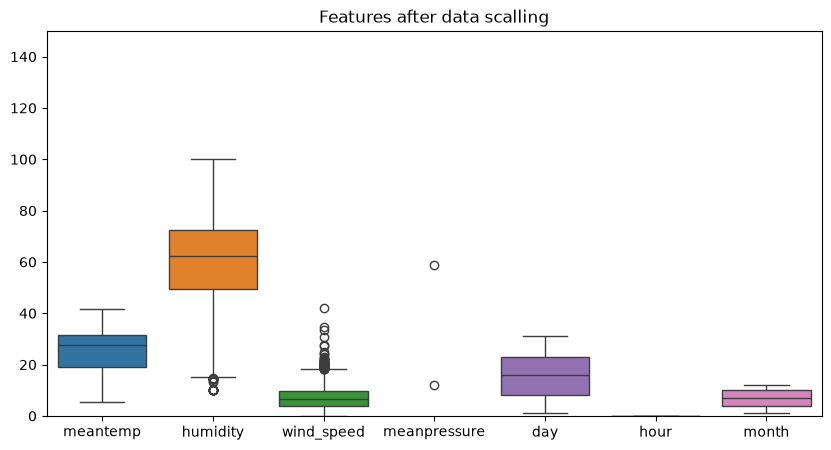

In [90]:
# Biểu đồ sau khi dữ liệu được chuẩn hóa
plt.figure(figsize=(10,5))
plt.title("Features after data scalling")
sns.boxplot(data)
plt.ylim(0, 150)
plt.show()

### Mô hình Linear Regression:

Mô hình hồi quy tuyến tính (Linear Regression) là phương pháp thống kê để mô hình hóa mối quan hệ giữa biến phụ thuộc và biến độc lập. Đây là một thuật toán học máy dùng để dự đoán một giá trị liên tục.
+ Hồi quy tuyến tính đơn biến: $$y = w_0 + w_1 x + \epsilon = 
\begin{pmatrix}
w_0 & w_1 \\
\end{pmatrix} 
\begin{pmatrix}
1 \\ x
\end{pmatrix} + \epsilon$$
+ Hồi quy tuyến tính đa biến $y = w^T x + b$: $$y = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n + \epsilon = 
\begin{pmatrix}
w_0 & w_1 & ... & w_n
\end{pmatrix} \begin{pmatrix}
1 \\ x_1 \\ ... \\ x_n
\end{pmatrix} + \epsilon$$

In [91]:
# Library
from sklearn.linear_model import LinearRegression

In [92]:
# Dự đoán mô hình Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

In [93]:
print(f"R2_score = {lr.score(x_test, y_test)}")
print(f"MAE = {mean_absolute_error(y_test, lr_pred)}")
print(f"MSE = {mean_squared_error(y_test, lr_pred)}")

R2_score = 0.38858072946658717
MAE = 4.90209386046598
MSE = 33.683620307923974


### Mô hình Support Vector Regression:

Mô hình Support Vector Regression (SVR) là biến thể của thuật toán Support Vector Machine (SVM), được sử dụng cho các bài toán hồi quy. SVR là phương pháp mạnh mẽ và hiệu quả trong việc xử lý bài toán với dữ liệu tuyến tính và phi tuyến.

Ý tưởng:
+ Tìm siêu phẳng khớp nhất với dữ liệu có độ rộng $2\epsilon$
+ Tối tiểu hóa sai số trong khoảng biên xác định trong ống (ống epsilon $\epsilon-tube$), điểm nằm ngoài ống $\epsilon$ là có sai số đáng kể tính phạt

#### 1. Dữ liệu dạng tuyến tính (Linear SVR):
+ Hàm dự báo: $f(x) = \langle w, x \rangle + b$ với $\langle w, x \rangle$ là tích vô hướng
+ Hàm mất mát $\epsilon$-insensitive:

$$L_{\epsilon}(y, f(x)) = \begin{cases} 0 & \text{nếu } \vert{}y - f(x)\vert{} \le \epsilon \\ \vert{}y - f(x)\vert{} - \epsilon & \text{nếu } \vert{}y - f(x)\vert{} > \epsilon \end{cases}$$

+ Bài toán tối ưu hóa:

$$\min_{w, b, \xi, \xi^*} \frac{1}{2} \Vert{}w\Vert{}^2 + C \sum_{i=1}^{N} (\xi_i + \xi_i^*)$$

+ Điều kiện ràng buộc: (C là tham số phạt, $\xi_i$ và $\xi_i^*$ là biến nới lỏng đo độ lệch)

$$\begin{cases}  y_i - \langle w, x_i \rangle - b \le \epsilon + \xi_i \\  \langle w, x_i \rangle + b - y_i \le \epsilon + \xi_i^* \\  \xi_i, \xi_i^* \ge 0 \quad \forall i = 1, \dots, N  \end{cases}$$

#### 2. Dữ liệu dạng phi tuyến (Kernel Trick):
Đối với dữ liệu không có mối quan hệ tuyến tính, SVR chiếu dữ liệu x từ không gian ban đầu sang không gian đặc trưng nhiều chiều hơn với hàm $\phi(x)$.

+ Hàm Kernel: 

$$K(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle = \exp\left(-\gamma \Vert{}x_i - x_j\Vert{}^2\right) \quad (\gamma > 0)$$

+ Phương trình dự báo: ($\alpha_i, \alpha_i^*$ là các nhân tử Lagrange thu được từ bài toán tối ưu hóa đối ngẫu)

$$f(x) = \sum_{i=1}^{N} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$

#### 3. Chạy chương trình SVR:

In [94]:
# Libraries
from sklearn.svm import SVR

In [95]:
# Dự đoán mô hình SVR
sr = SVR()
sr.fit(x_train, y_train)
sr_pred = sr.predict(x_test)

In [96]:
print(f"R2_score = {sr.score(x_test, y_test)}")
print(f"MAE = {mean_absolute_error(y_test, sr_pred)}")
print(f"MSE = {mean_squared_error(y_test, sr_pred)}")

R2_score = 0.9185068198951422
MAE = 1.6724490810613306
MSE = 4.489530292269856


### Mô hình Random Forest Regression:

Mô hình tạo một tập hợp gồm $B$ cây quyết định độc lập $\{T_1, T_2, \dots, T_B\}$, từng cây quyết định $T_b$ sẽ chia không gian đặc trưng thành $K$ vùng không chồng lấp $R_1, R_2, \dots, R_K$.

#### 1. Tiêu chuẩn phân nhánh tại mỗi nút:
Tìm đặc trưng $j$ và ngưỡng $s$ chia nút thành 2 vùng $R_1(j,s) = \{x \mid x_j \le s\}$ và $R_2(j,s) = \{x \mid x_j > s\}$ sao cho tối thiểu hóa Tổng bình phương sai số (RSS/MSE):$$\min_{j, s} \left[ \sum_{x_i \in R_1(j,s)} (y_i - c_1)^2 + \sum_{x_i \in R_2(j,s)} (y_i - c_2)^2 \right]$$

#### 2. Giá trị dự báo tại nút lá:
Tại vùng $R_k$, giá trị đại diện $c_k$ là trung bình cộng các nhãn $y_i$ thuộc vùng đó:$$c_k = \frac{1}{N_k} \sum_{x_i \in R_k} y_i$$

#### 3. Quá trình dự báo:
Giá trị dự báo cuối cùng $\hat{y}$ là trung bình cộng kết quả đầu ra của tất cả $B$ cây trong rừng:$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

#### 4. Chạy chương trình RFR:

In [97]:
# Library
from sklearn.ensemble import RandomForestRegressor

In [98]:
# Mô hình Random Forest Regression
rr = RandomForestRegressor()
rr.fit(x_train, y_train)
rr_pred = rr.predict(x_test)

In [99]:
print(f"R2_score = {rr.score(x_test, y_test)}")
print(f"MAE = {mean_absolute_error(y_test, rr_pred)}")
print(f"MSE = {mean_squared_error(y_test, rr_pred)}")

R2_score = 0.8176000640217256
MAE = 2.410269861331148
MSE = 10.048571387555054
